# Part II: Investigating the Vanishing Gradient Problem [20 pts]
Experimentally demonstrate the vanishing gradient problem in deep CNNs and understand how ResNet's architecture mitigates it. You will also explore other key CNN concepts through additional experiments.

## Step 1: Create a deeper version of your VGG-16 network (VGG-Deep)

Dataset Statistics: {'dogs': 10000, 'food': 10000, 'vehicles': 10000}


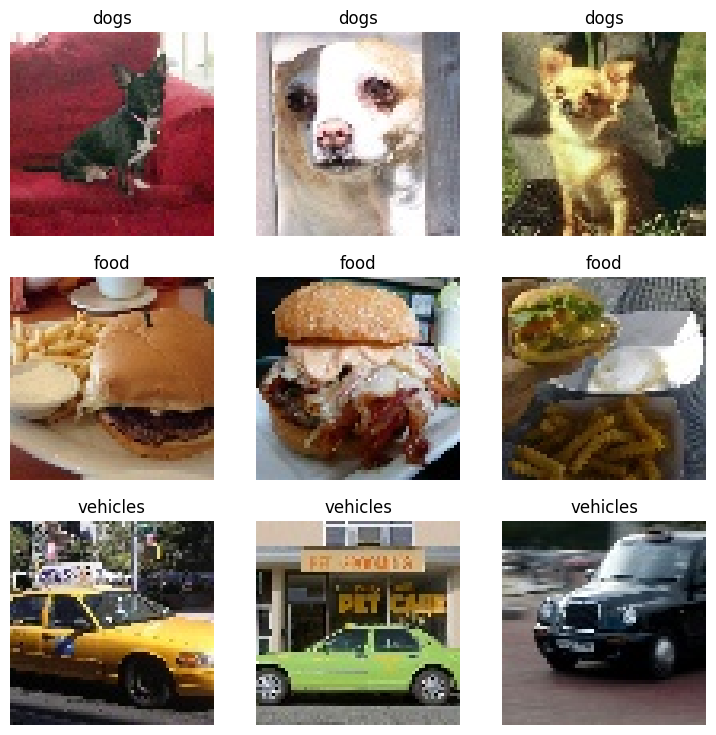

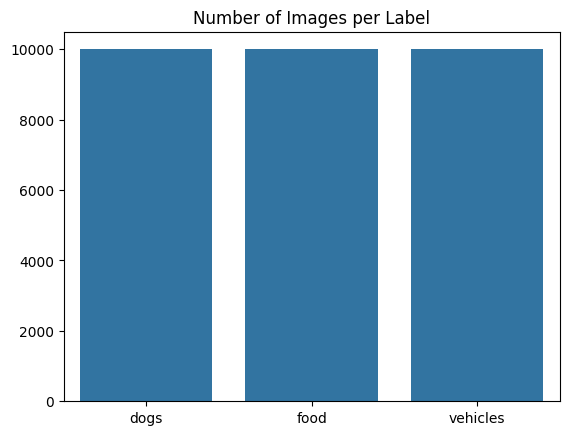

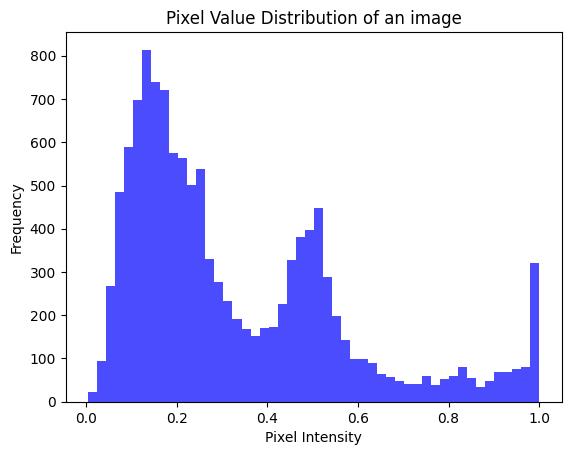

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split,Subset
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support
import seaborn as sns
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)
import time


import zipfile

data_dir = "/content/cnn_dataset"
zip_file_path = "cnn_dataset.zip"

with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
    zip_ref.extractall(data_dir)

transform_tensor = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform_tensor)

classes = ['dogs', 'food', 'vehicles']

transform_tensor = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform_tensor)

class_counts = {class_name: len(os.listdir(os.path.join(data_dir, class_name))) for class_name in classes}
print("Dataset Statistics:", class_counts)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i, class_name in enumerate(classes):
    class_indices = [idx for idx, (_, label) in enumerate(dataset) if label == i]
    sample_images = [dataset[idx][0].permute(1, 2, 0).numpy() for idx in class_indices[:3]]
    for j, img in enumerate(sample_images):
        axes[i, j].imshow(img)
        axes[i, j].set_title(classes[i])
        axes[i, j].axis('off')
plt.show()

# Bar chart of class distribution
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Number of Images per Label")
plt.show()

sample_img = dataset[0][0].numpy().flatten()
plt.hist(sample_img, bins=50, color='blue', alpha=0.7)
plt.title("Pixel Value Distribution of an image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


dataset = datasets.ImageFolder(root=data_dir, transform=transform)\

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
print(train_size, val_size, test_size)

# Create DataLoaders
def get_dataloader(dataset, batch_size=32):
    return DataLoader(dataset, batch_size=batch_size,num_workers=4, shuffle=True,  pin_memory=True)

dataloaders = {
    'train32': get_dataloader(train_dataset, batch_size=32),
    'train64': get_dataloader(train_dataset, batch_size=64),
    'val32': get_dataloader(val_dataset, batch_size=32),
    'val64': get_dataloader(val_dataset, batch_size=64),
    'test32': get_dataloader(test_dataset, batch_size=32),
    'test64': get_dataloader(test_dataset, batch_size=64)
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

21000 4500 4500
cuda


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Step 2: Training VGG-Deep

In [14]:
import torch
import torch.nn as nn

class VGGDeep(nn.Module):
    def __init__(self, num_classes=3):
        super(VGGDeep, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096), nn.ReLU(),
            nn.Linear(4096, 4096), nn.ReLU(),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

vgg_deep = VGGDeep(num_classes=3).to(device)
print(vgg_deep)


VGGDeep(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1),

In [38]:
import torch
model_path = "/content/a1_part_2_sashikum.pt"
torch.save(vgg_deep.state_dict(), model_path)

In [18]:
import torch
import torch.nn.functional as F

def test_model(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, device: torch.device, criterion) -> tuple:
    model.eval()
    test_loss, correct_test = 0.0, 0
    test_predictions, labels_test_total, test_probabilities = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            test_output = model(inputs)
            loss = criterion(test_output, labels)
            test_loss += loss.item()

            probs = F.softmax(test_output, dim=1)
            preds = torch.argmax(probs, dim=1)

            correct_test += (preds == labels).sum().item()
            test_predictions.extend(preds.cpu().tolist())
            labels_test_total.extend(labels.cpu().tolist())
            test_probabilities.extend(probs.cpu().tolist())

    test_loss /= len(dataloader)
    test_accuracy = 100 * correct_test / len(dataloader.dataset)

    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")

    return torch.tensor(labels_test_total), torch.tensor(test_predictions), torch.tensor(test_probabilities), test_loss, test_accuracy


In [19]:
import torch.nn.functional as F
import gc

def train_and_validate(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    device: torch.device,
    epochs: int,
    optimizer: torch.optim.Optimizer,
    criterion,
    l2_scheduler: bool = False,
    early_stopping: int = None,
):
    train_losses, train_accuracies = [], []
    validation_losses, validation_accuracies = [], []
    epoch_times = []
    best_val_accuracy = 0.0
    epochs_without_improvement = 0
    start_time = time.time()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.1, patience=3, verbose=True, min_lr=1e-6
    )

    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        gc.collect()
        torch.cuda.empty_cache()


        train_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if l2_scheduler:
                l2_loss = sum(torch.norm(param) for param in model.parameters())
                loss += 5e-4 * l2_loss

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(correct_train / total_train)


        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                predicted = torch.argmax(outputs, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_loss_epoch = val_loss / len(val_loader)
        val_acc_epoch = correct_val / total_val
        validation_losses.append(val_loss_epoch)
        validation_accuracies.append(val_acc_epoch)

        scheduler.step(val_acc_epoch)

        if val_acc_epoch > best_val_accuracy:
            best_val_accuracy = val_acc_epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if early_stopping and epochs_without_improvement >= early_stopping:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)


        print(f"Epoch {epoch+1}/{epochs} - Time: {epoch_time:.2f} sec")
        print(f"Training Loss: {train_losses[-1]:.4f}, Accuracy: {train_accuracies[-1]:.4f}")
        print(f"Validation Loss: {validation_losses[-1]:.4f}, Accuracy: {validation_accuracies[-1]:.4f}")

    total_time = time.time() - start_time
    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    print(f"\nTotal Training Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
    print(f"Average Time per Epoch: {avg_epoch_time:.2f} seconds")

    return train_losses, train_accuracies, validation_losses, validation_accuracies

In [20]:
def convert_to_numpy(tensor):
    """Convert PyTorch tensor to NumPy array safely."""
    return tensor.cpu().numpy() if isinstance(tensor, torch.Tensor) else np.array(tensor)

def plot_metric_curve(train_values, val_values, test_value, xlabel, ylabel, title, legend_labels):
    """Helper function to plot metric curves."""
    plt.figure(figsize=(12, 5))
    plt.plot(train_values, label=legend_labels[0])
    plt.plot(val_values, label=legend_labels[1])
    plt.axhline(y=test_value, color='r', linestyle='--', label=legend_labels[2])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

def metrics(
    labels_test_total, predicted_test_classes, test_probabilities,
    test_loss, train_losses, validation_losses,
    train_accuracies, validation_accuracies
):
    labels_test_np = convert_to_numpy(labels_test_total)
    predicted_test_np = convert_to_numpy(predicted_test_classes)
    test_probabilities_np = convert_to_numpy(test_probabilities)

    accuracy = accuracy_score(labels_test_np, predicted_test_np)
    precision = precision_score(labels_test_np, predicted_test_np, average='micro')
    recall = recall_score(labels_test_np, predicted_test_np, average='micro')
    f1 = f1_score(labels_test_np, predicted_test_np, average='micro')
    classify_report = classification_report(labels_test_np, predicted_test_np)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classify_report)

    plot_metric_curve(train_losses, validation_losses, test_loss,
                      xlabel='Epoch', ylabel='Loss', title='Loss Curve',
                      legend_labels=['Training Loss', 'Validation Loss', 'Test Loss'])

    plot_metric_curve(train_accuracies, validation_accuracies, accuracy,
                      xlabel='Epoch', ylabel='Accuracy', title='Accuracy Curve',
                      legend_labels=['Training Accuracy', 'Validation Accuracy', 'Test Accuracy'])

    cm = confusion_matrix(labels_test_np, predicted_test_np)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [21]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

drop = 0.5
schedular = True

## Step 3: Gradient analysis

VGG Deep
Epoch 1/10 - Time: 354.22 sec
Training Loss: 1.0646, Accuracy: 0.5622
Validation Loss: 0.8169, Accuracy: 0.6087
Epoch 2/10 - Time: 354.48 sec
Training Loss: 0.6486, Accuracy: 0.7243
Validation Loss: 0.6931, Accuracy: 0.6973
Epoch 3/10 - Time: 355.23 sec
Training Loss: 0.5742, Accuracy: 0.7599
Validation Loss: 0.6299, Accuracy: 0.7378
Epoch 4/10 - Time: 355.47 sec
Training Loss: 0.5401, Accuracy: 0.7822
Validation Loss: 0.7755, Accuracy: 0.6484
Epoch 5/10 - Time: 354.75 sec
Training Loss: 0.5103, Accuracy: 0.7918
Validation Loss: 1.0341, Accuracy: 0.5742
Epoch 6/10 - Time: 354.94 sec
Training Loss: 0.4858, Accuracy: 0.8041
Validation Loss: 0.4820, Accuracy: 0.8080
Epoch 7/10 - Time: 356.15 sec
Training Loss: 0.4641, Accuracy: 0.8128
Validation Loss: 0.8285, Accuracy: 0.7244
Epoch 8/10 - Time: 356.25 sec
Training Loss: 0.4468, Accuracy: 0.8216
Validation Loss: 0.8217, Accuracy: 0.6320
Epoch 9/10 - Time: 356.44 sec
Training Loss: 0.4242, Accuracy: 0.8307
Validation Loss: 1.5034, 

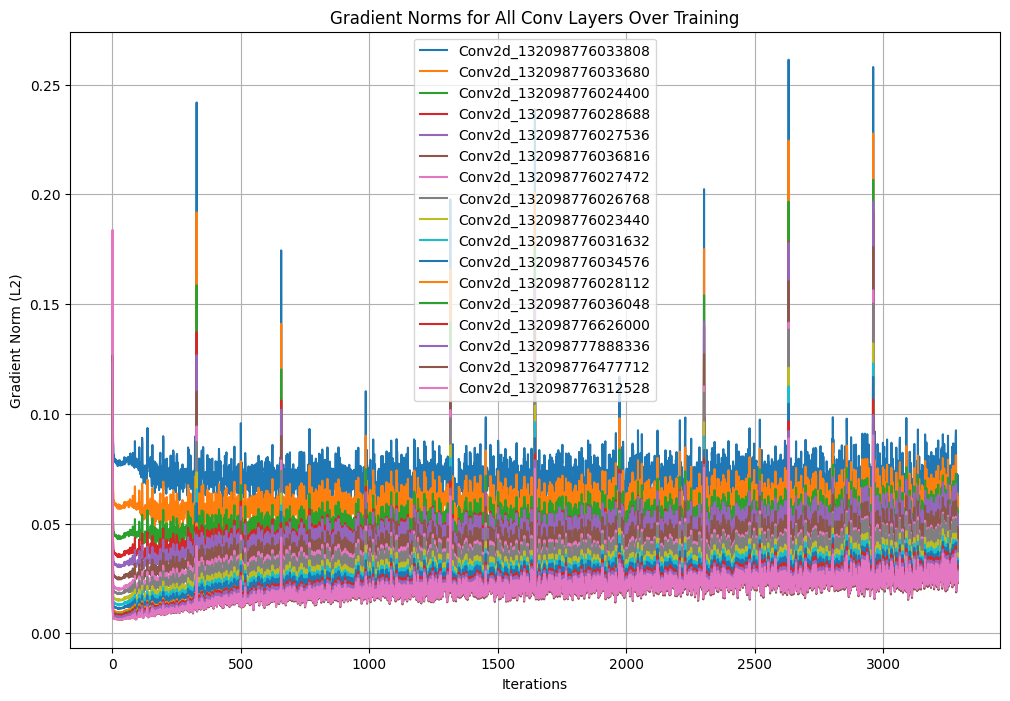

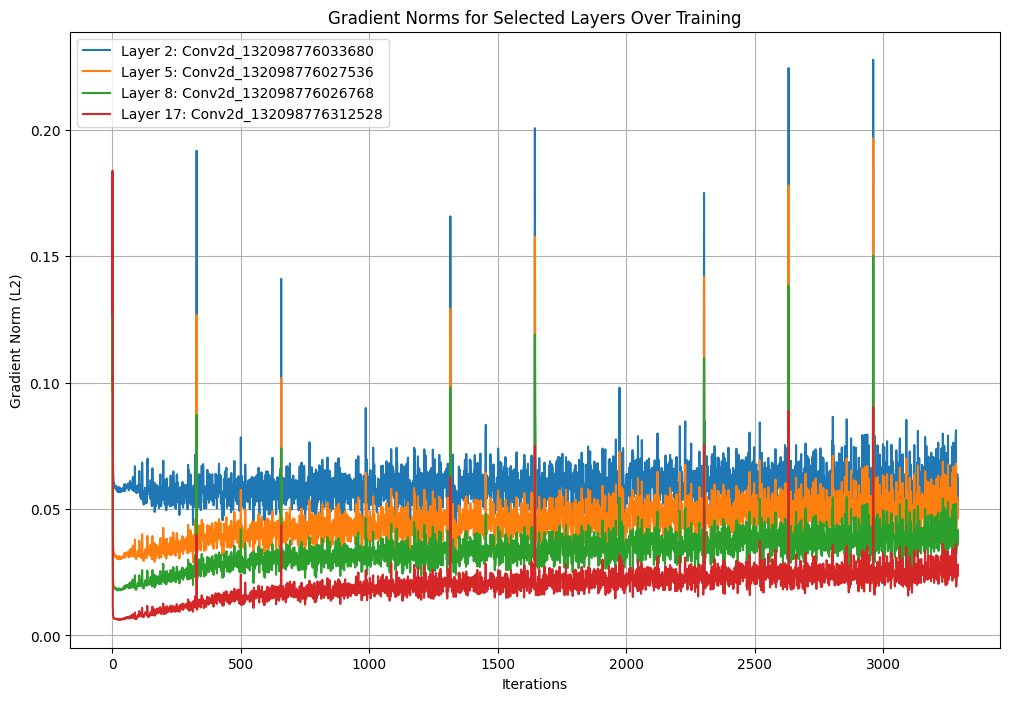

In [22]:
#He Weight Initialization
#Adam Optimizer
#64 Batch Size

print('VGG Deep')
gradientNorms = {}

def gradientHook(module, gradientInput, gradientOutput):
    if gradientOutput[0] is not None:
        gradientNorm = gradientOutput[0].detach().norm(p=2).item()
        layer_name = f"{module.__class__.__name__}_{id(module)}"

        if layer_name not in gradientNorms:
            gradientNorms[layer_name] = []

        gradientNorms[layer_name].append(gradientNorm)


vgg_deep = VGGDeep(num_classes=3).to(device)

for layer in vgg_deep.modules():
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
        if layer.bias is not None:
            nn.init.zeros_(layer.bias)

for layer in vgg_deep.features:
    if isinstance(layer, nn.Conv2d):
        layer.register_full_backward_hook(gradientHook)

optimizerDeep = torch.optim.SGD(vgg_deep.parameters(), lr=0.005)
criterionDeep = nn.CrossEntropyLoss()

trainLossesDeep, trainAccuraciesDeep, valLossesDeep, valAccuraciesDeep = train_and_validate(
    model=vgg_deep,
    train_loader=dataloaders['train64'],
    val_loader=dataloaders['val64'],
    device=device,
    optimizer=optimizerDeep,
    criterion=criterionDeep,
    epochs=10,
    l2_scheduler=False
)

vgg_deep_data = {
    "train_losses": trainLossesDeep,
    "train_accuracies": trainAccuraciesDeep,
    "validation_losses": valLossesDeep,
    "validation_accuracies": valAccuraciesDeep,
    "gradient_norms": gradientNorms
}

output_file = "/content/model_vgg_deep_values.pkl"

print("Layers with recorded gradient norms:", gradientNorms.keys())


plt.figure(figsize=(12, 8))
for layer_name, norms in gradientNorms.items():
    plt.plot(norms, label=layer_name)

plt.title("Gradient Norms for All Conv Layers Over Training")
plt.xlabel("Iterations")
plt.ylabel("Gradient Norm (L2)")
plt.legend()
plt.grid(True)
plt.show()

selected_layers = [1, 4, 7, len(gradientNorms)-1]

plt.figure(figsize=(12, 8))
for idx, (layer_name, norms) in enumerate(gradientNorms.items()):
    if idx in selected_layers:
        plt.plot(norms, label=f"Layer {idx+1}: {layer_name}")

plt.title("Gradient Norms for Selected Layers Over Training")
plt.xlabel("Iterations")
plt.ylabel("Gradient Norm (L2)")
plt.legend()
plt.grid(True)
plt.show()

## Step 4: Comparison with VGG-16 and ResNet-18

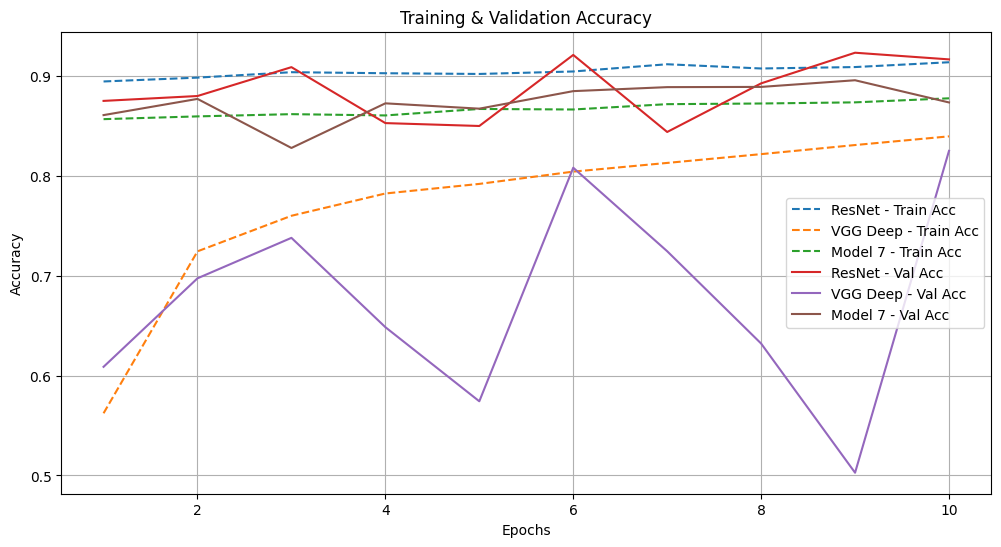

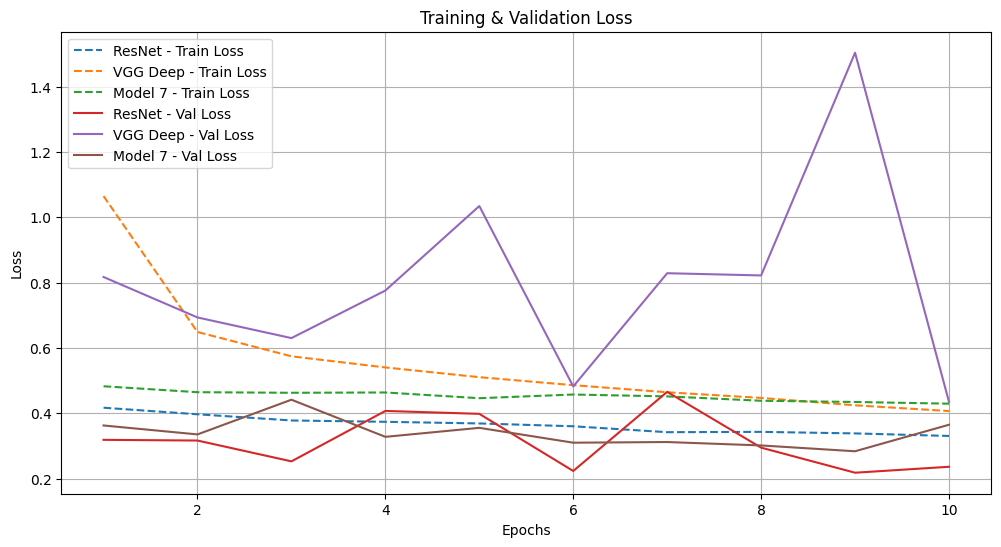

In [28]:
import pickle
files = {
    "ResNet": "/content/model_resnet_enn_values_2.pkl",
    "VGG Deep": "/content/model_vgg_deep_values.pkl",
    "Model 7": "/content/model_7_values_2.pkl"
}

loaded_models = {}

for model_name, file_path in files.items():
    with open(file_path, "rb") as f:
        loaded_models[model_name] = pickle.load(f)
train_accuracies = {name: data["train_accuracies"] for name, data in loaded_models.items()}
val_accuracies = {name: data["validation_accuracies"] for name, data in loaded_models.items()}
train_losses = {name: data["train_losses"] for name, data in loaded_models.items()}
val_losses = {name: data["validation_losses"] for name, data in loaded_models.items()}

epochs = range(1, len(next(iter(train_accuracies.values()))) + 1)

plt.figure(figsize=(12, 6))
for model_name, acc in train_accuracies.items():
    plt.plot(epochs, acc, label=f"{model_name} - Train Acc", linestyle="--")

for model_name, acc in val_accuracies.items():
    plt.plot(epochs, acc, label=f"{model_name} - Val Acc", linestyle="-")

plt.title("Training & Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
for model_name, loss in train_losses.items():
    plt.plot(epochs, loss, label=f"{model_name} - Train Loss", linestyle="--")

for model_name, loss in val_losses.items():
    plt.plot(epochs, loss, label=f"{model_name} - Val Loss", linestyle="-")

plt.title("Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Step 5: Investigate and analyze more setups

# **Subset Experiment**

In [29]:
from torch.utils.data import Subset
def subsetMethod(dataset, samplesCount=1000):
    indices = {i: [] for i in range(len(dataset.classes))}

    for i, (_, label) in enumerate(dataset):
        indices[label].append(i)

    subIndex = []
    for indices in indices.values():
        subIndex += indices[:samplesCount]

    return Subset(dataset, subIndex)

datasetSmall = subsetMethod(dataset, 1000)

trainSubset = int(len(datasetSmall) * 0.7)
valSubset = len(datasetSmall) - trainSubset
trainData, valData = random_split(datasetSmall, [trainSubset, valSubset])

trainLoader = DataLoader(trainData, batch_size=32)
valLoader = DataLoader(valData, batch_size=32)


In [30]:
class VGGKernel(nn.Module):
    def __init__(self, kernel_size=3, padding=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=kernel_size, padding=padding), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=kernel_size, padding=padding), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=kernel_size, padding=padding), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_3_Kernel = VGGKernel(kernel_size=3, padding=1).to(device)
model_5_Kernel = VGGKernel(kernel_size=5, padding=2).to(device)
model_7_Kernel = VGGKernel(kernel_size=7, padding=3).to(device)



In [31]:
class VGGMaxPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
model_max = VGGMaxPool().to(device)

In [32]:
class VGGAveragePool(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_avg = VGGAveragePool().to(device)

In [33]:
class VGGActivationFunc(nn.Module):
    def __init__(self, activationfunc=nn.ReLU):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), activationfunc(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), activationfunc(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), activationfunc(),
            nn.MaxPool2d(2,2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), activationfunc(),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_relu = VGGActivationFunc(activationfunc=nn.ReLU).to(device)
model_leakyrelu = VGGActivationFunc(activationfunc=nn.LeakyReLU).to(device)
model_elu = VGGActivationFunc(activationfunc=nn.ELU).to(device)
model_gelu = VGGActivationFunc(activationfunc=nn.GELU).to(device)




 Training Model: Kernel3x3
Epoch 1/5 - Time: 27.68 sec
Training Loss: 0.5826, Accuracy: 0.7881
Validation Loss: 0.5167, Accuracy: 0.7900
Epoch 2/5 - Time: 27.29 sec
Training Loss: 0.5189, Accuracy: 0.8038
Validation Loss: 0.5618, Accuracy: 0.7733
Epoch 3/5 - Time: 27.98 sec
Training Loss: 0.4974, Accuracy: 0.8219
Validation Loss: 0.4998, Accuracy: 0.7878
Epoch 4/5 - Time: 27.79 sec
Training Loss: 0.4737, Accuracy: 0.8238
Validation Loss: 0.4776, Accuracy: 0.8033
Epoch 5/5 - Time: 27.26 sec
Training Loss: 0.4632, Accuracy: 0.8195
Validation Loss: 0.4749, Accuracy: 0.8111

Total Training Time: 137.99 seconds (2.30 minutes)
Average Time per Epoch: 27.60 seconds

 Training Model: Kernel5x5
Epoch 1/5 - Time: 28.47 sec
Training Loss: 0.9070, Accuracy: 0.6167
Validation Loss: 0.7003, Accuracy: 0.7100
Epoch 2/5 - Time: 27.88 sec
Training Loss: 0.6457, Accuracy: 0.7524
Validation Loss: 0.5984, Accuracy: 0.7433
Epoch 3/5 - Time: 28.40 sec
Training Loss: 0.5594, Accuracy: 0.7905
Validation Loss:

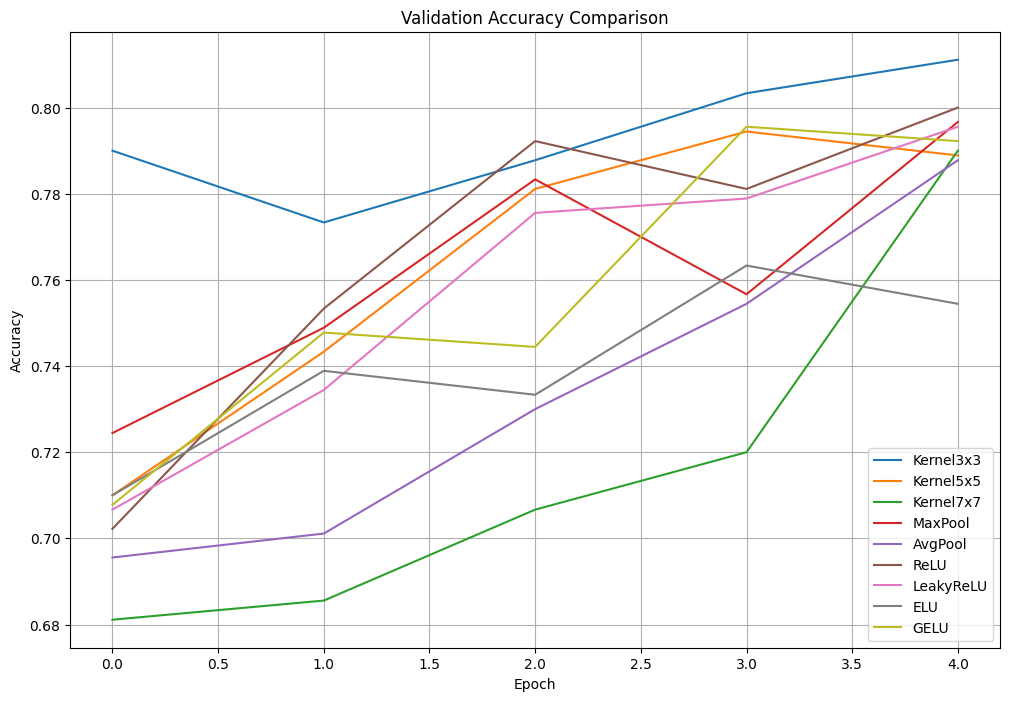

In [36]:
models = [
    (model_3_Kernel, 'Kernel3x3'),
    (model_5_Kernel, 'Kernel5x5'),
    (model_7_Kernel, 'Kernel7x7'),
    (model_max, 'MaxPool'),
    (model_avg, 'AvgPool'),
    (model_relu, 'ReLU'),
    (model_leakyrelu, 'LeakyReLU'),
    (model_elu, 'ELU'),
    (model_gelu, 'GELU')
]

criterion = nn.CrossEntropyLoss()
epochs = 5
schedular = True

trained_results = []

for modelSmall, name in models:
    print(f"\n{'='*28} \n Training Model: {name}")

    optimizer = torch.optim.Adam(modelSmall.parameters(), lr=0.001)

    train_losses, train_accuracies, val_losses, val_accuracies = train_and_validate(
        model=modelSmall,
        train_loader=trainLoader,
        val_loader=valLoader,
        device=device,
        optimizer=optimizer,
        criterion=criterion,
        epochs=epochs,
        l2_scheduler=schedular
    )

    trained_results.append({
        'name': name,
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    })



plt.figure(figsize=(12, 8))

for result in trained_results:
    plt.plot(result['val_accuracies'], label=result['name'])

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



## Step 6: Analysis and discussion

a. Analyze your gradient norm plots. Do they demonstrate the vanishing gradient problem? Explain how the gradient norm changes as you move deeper into VGG-Deep. Be specific and quantitative (e.g., "The gradient norm of layer 2 is X times larger than the gradient norm of layer 10").

<span style='color:green'>ans.</span>
As we can see the plot in the VGG-Deep model, the gradient norm in the initial layer is larger (Green, orange and Blue) than the deeper 17th layer (Red). This confirms the vanishing gradient problem. In layer 2 (Blue) Norm is much larger than the 17th layer. As the Iteration goes, gradient norm of Layer 2 is four-five times larger than the 17th layer. This shows deeper layer struggles with gradient vanishing.

b. Explain why the vanishing gradient problem occurs in deep networks. Relate this to the backpropagation algorithm and the chain rule. Discuss how the repeated multiplication of small gradients can lead to extremely small values in earlier layers.

<span style='color:green'>ans.</span>
Vanishing gradient problem is a effective problem which occurs when we train deeper model, where the gradient value gets smaller and smaller exponentially as the training process continues and become zero. This is because of back propagation through each layer. This leads to slow training of the models. In deep learning, backpropagation is used to update the weights of the network using gradient descent. The gradients of the loss function with respect to each weight are calculated using the chain rule.

c. Explain how ResNet's architecture (residual connections) helps alleviate the vanishing gradient problem. Explain how the identity mapping allows gradients to flow more easily through the network.

<span style='color:green'>ans.</span>
The vanishing gradient problem makes it difficult to train deep neural networks because the gradients become too small in earlier layers. ResNet introduces residual connections to help preserve the gradient flow and enable deep networks to learn effectively. The residual function the network learns how much to change the input instead of learning the entire function from scratch.

d. Discuss the theoretical impact of batch normalization on the vanishing/exploding gradient problem. Explain how it helps stabilize and accelerate training.

<span style='color:green'>ans.</span>
Batch Normalization is used to stabilize and accelerate training in deep neural networks. It reduces the vanishing gradient problem by normalizing activations at each layer. Since the batch normalization keeps the activations in a controlled range, the gradients do not shrink in the deeper layers. This prevents the deep layers from receiving tiny or massive gradient updates. Normalization makes the loss function less sensitive to parameter changes, leading to smoother optimization. Since the activation function is normalized, higher learning rate can be used and can be trained faster.

e. Summarize the key findings from your three chosen investigations.

<span style='color:green'>ans.</span>
Vanishing gradient problem is a effective problem which occurs when we train deeper model, where the gradient value gets smaller and smaller exponentially as the training process continues and become zero. This is because of back propagation through each layer.
ResNet introduces residual connections to help preserve the gradient flow and enable deep networks to learn effectively.
Since the batch normalization keeps the activations in a controlled range, the gradients do not shrink in the deeper layers. This prevents the deep layers from receiving tiny or massive gradient updates. Normalization makes the loss function less sensitive to parameter changes, leading to smoother optimization.

## References:

https://www.kdnuggets.com/2022/02/vanishing-gradient-problem.html#:~:text=The%20vanishing%20gradient%20problem%20is,activation%20function%20such%20as%20ReLU.

https://datascience.stackexchange.com/questions/95160/how-batch-normalization-layer-resolve-the-vanishing-gradient-problem

https://musstafa0804.medium.com/vgg-in-depth-48ec68d71a92